In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [17]:
# Load the dataset

df = pd.read_csv("dataset/creditcard.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Dataset loaded successfully!
Dataset Shape: (284807, 31)

First 5 Rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [18]:
# Prepare features and target

X = df.drop("Class", axis=1)
y = df["Class"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

Features Shape: (284807, 30)
Target Shape: (284807,)

Target Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [19]:
# Stratified train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training Data Shape: (227845, 30)
Testing Data Shape: (56962, 30)

Training Class Distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing Class Distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [20]:
# Handle class imbalance using SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42,
    sampling_strategy=0.5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original Training Data:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nOriginal Training Shape:", X_train.shape)
print("SMOTE Training Shape:", X_train_smote.shape)

Original Training Data:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    113725
Name: count, dtype: int64

Original Training Shape: (227845, 30)
SMOTE Training Shape: (341176, 30)


In [30]:
import os

os.makedirs("screenshots", exist_ok=True)

print("Screenshots folder ready!")

Screenshots folder ready!


Non-Fraud Transactions: 284315
Fraud Transactions: 492
Fraud Percentage: 0.1727%


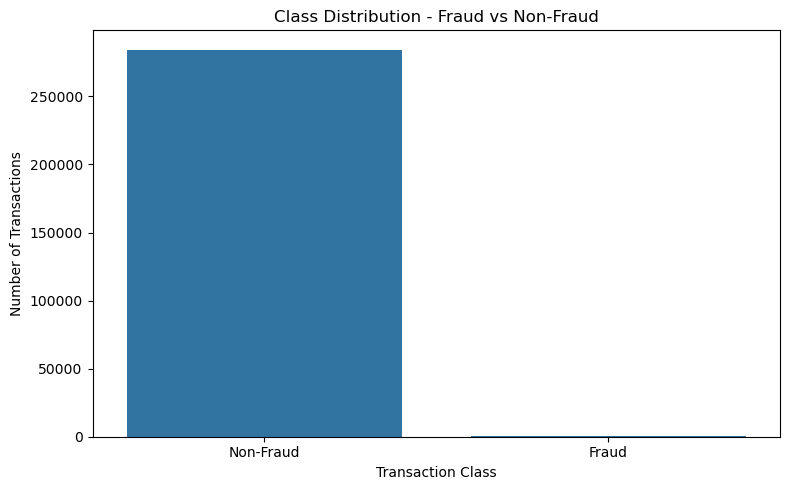

In [31]:
# Class Imbalance Analysis

class_counts = df["Class"].value_counts()

fraud_count = class_counts[1]
non_fraud_count = class_counts[0]

fraud_percentage = (fraud_count / len(df)) * 100

print("Non-Fraud Transactions:", non_fraud_count)
print("Fraud Transactions:", fraud_count)
print(f"Fraud Percentage: {fraud_percentage:.4f}%")

plt.figure(figsize=(8, 5))

sns.barplot(
    x=["Non-Fraud", "Fraud"],
    y=[non_fraud_count, fraud_count]
)

plt.title("Class Distribution - Fraud vs Non-Fraud")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig(
    "screenshots/01_class_imbalance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

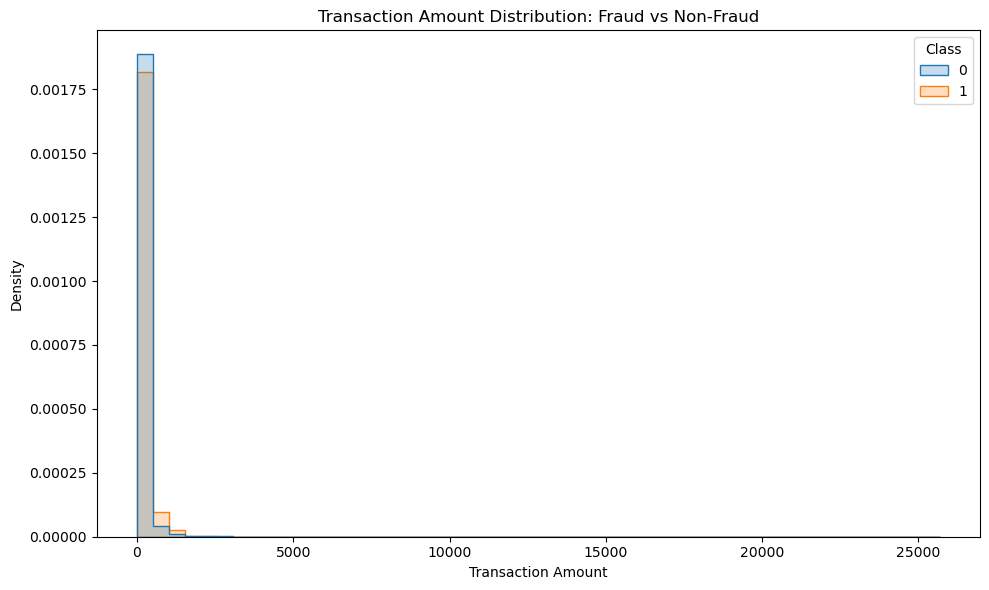

In [32]:
# Transaction Amount Distribution: Fraud vs Non-Fraud

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")

plt.tight_layout()

plt.savefig(
    "screenshots/02_transaction_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

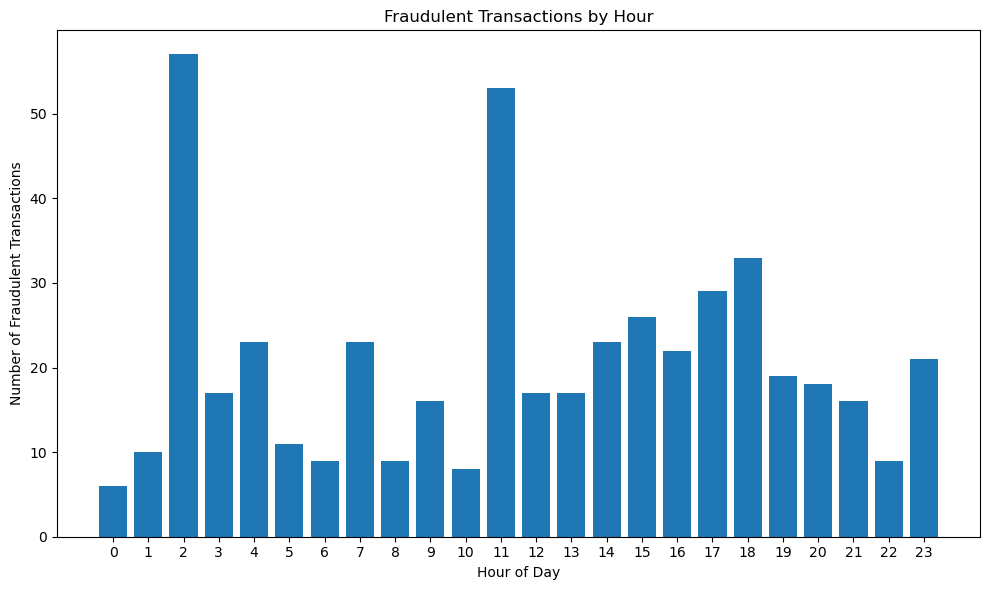

In [33]:
# Time-of-Day Analysis

df["Hour"] = (df["Time"] // 3600) % 24

hourly_fraud = df.groupby("Hour")["Class"].sum()

plt.figure(figsize=(10, 6))

plt.bar(
    hourly_fraud.index,
    hourly_fraud.values
)

plt.title("Fraudulent Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraudulent Transactions")

plt.xticks(range(24))

plt.tight_layout()

plt.savefig(
    "screenshots/03_time_of_day_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

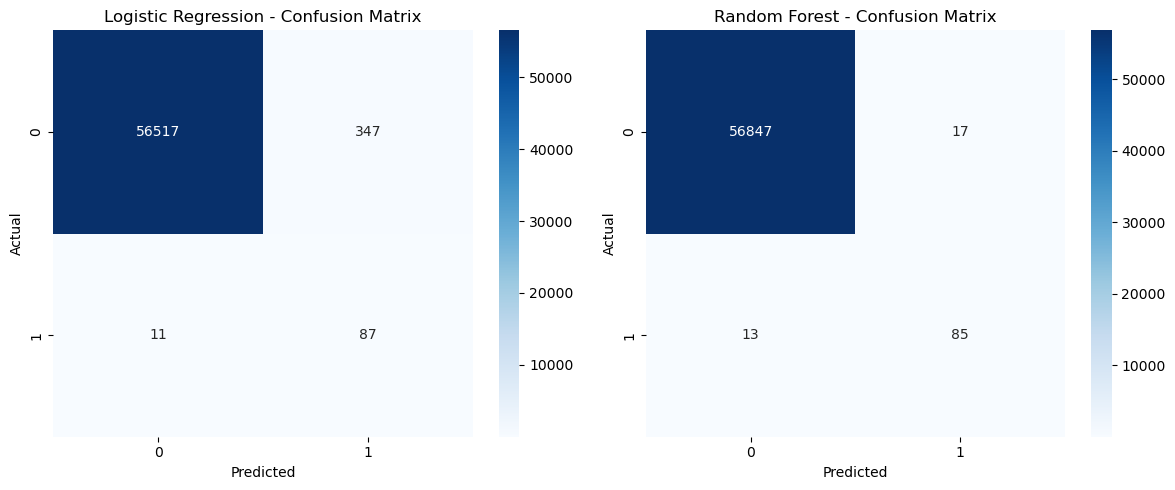

In [34]:
# Confusion Matrices for both models

from sklearn.metrics import confusion_matrix

logistic_cm = confusion_matrix(y_test, logistic_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Logistic Regression - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1]
)

axes[1].set_title("Random Forest - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "screenshots/04_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# Feature scaling for Logistic Regression

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled Training Shape:", X_train_smote_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled Training Shape: (341176, 30)
Scaled Testing Shape: (56962, 30)


In [22]:
# Train Logistic Regression model

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_smote_scaled,
    y_train_smote
)

logistic_pred = logistic_model.predict(X_test_scaled)
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [23]:
# Train Random Forest model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [24]:
# Evaluate both models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Logistic Regression metrics
logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(y_test, logistic_pred)
logistic_recall = recall_score(y_test, logistic_pred)
logistic_f1 = f1_score(y_test, logistic_pred)
logistic_auc = roc_auc_score(y_test, logistic_prob)

# Random Forest metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("===== LOGISTIC REGRESSION =====")
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1-Score : {logistic_f1:.4f}")
print(f"AUC-ROC  : {logistic_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, logistic_pred, zero_division=0))

print("\n===== RANDOM FOREST =====")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"AUC-ROC  : {rf_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, zero_division=0))

===== LOGISTIC REGRESSION =====
Accuracy : 0.9937
Precision: 0.2005
Recall   : 0.8878
F1-Score : 0.3271
AUC-ROC  : 0.9758

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.20      0.89      0.33        98

    accuracy                           0.99     56962
   macro avg       0.60      0.94      0.66     56962
weighted avg       1.00      0.99      1.00     56962


===== RANDOM FOREST =====
Accuracy : 0.9995
Precision: 0.8333
Recall   : 0.8673
F1-Score : 0.8500
AUC-ROC  : 0.9740

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.87      0.85        98

    accuracy                           1.00     56962
   macro avg       0.92      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962



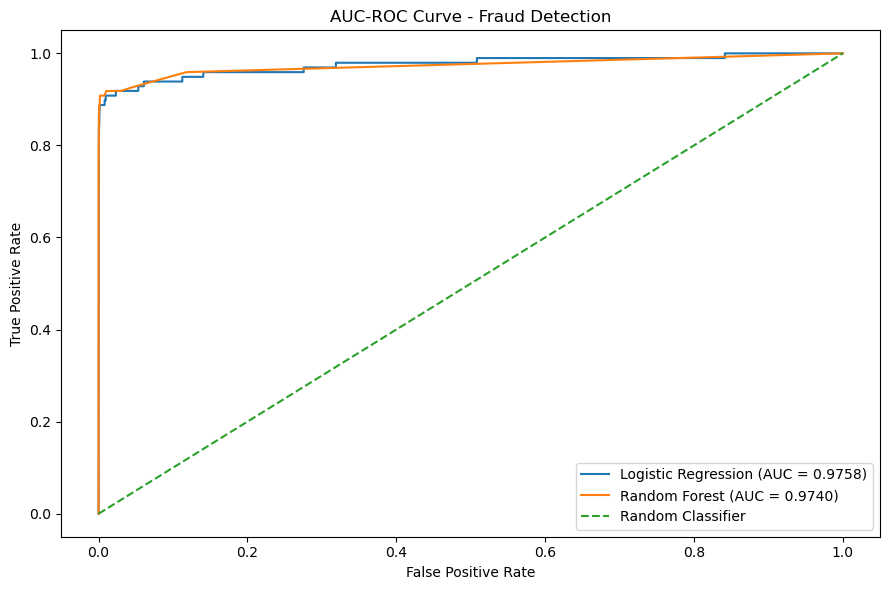

In [35]:
# AUC-ROC Curve

from sklearn.metrics import roc_curve

logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(9, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.4f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("AUC-ROC Curve - Fraud Detection")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()

plt.savefig(
    "screenshots/05_auc_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

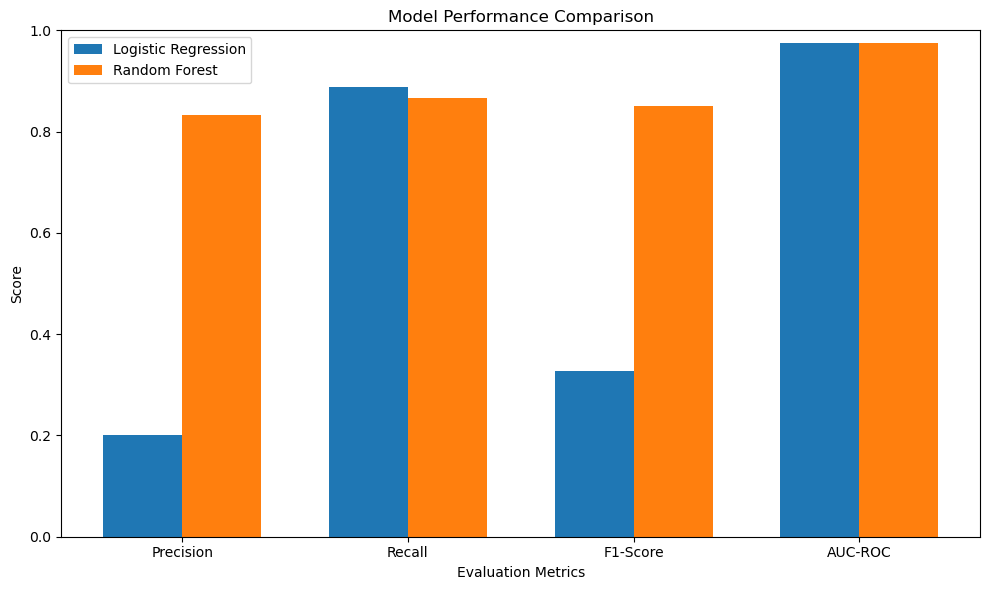

In [37]:
# Model Performance Comparison

plt.figure(figsize=(10, 6))

metrics = ["Precision", "Recall", "F1-Score", "AUC-ROC"]

logistic_values = [
    logistic_precision,
    logistic_recall,
    logistic_f1,
    logistic_auc
]

rf_values = [
    rf_precision,
    rf_recall,
    rf_f1,
    rf_auc
]

x = np.arange(len(metrics))
width = 0.35

plt.bar(
    x - width / 2,
    logistic_values,
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width / 2,
    rf_values,
    width,
    label="Random Forest"
)

plt.title("Model Performance Comparison")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()

plt.savefig(
    "screenshots/07_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Top 10 Important Features:


,Importance
V14,0.207699
V10,0.136484
V12,0.101374
V17,0.098539
V4,0.095629
V3,0.073246
V11,0.058493
V16,0.043208
V2,0.039917
V9,0.028585


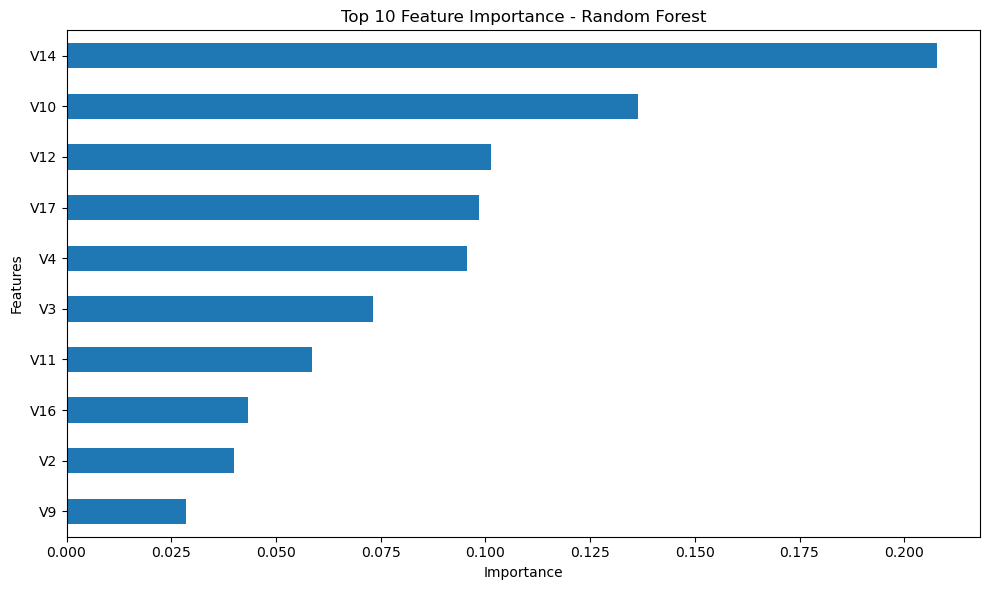

In [36]:
# Random Forest Feature Importance

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 Important Features:")
display(
    feature_importance.head(10).to_frame("Importance")
)

plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()

plt.savefig(
    "screenshots/06_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Precision vs Recall Trade-off

In fraud detection, both Precision and Recall are important, but they represent different objectives.

- **Precision** measures how many transactions predicted as fraudulent are actually fraudulent.
- **Recall** measures how many of the actual fraudulent transactions are correctly detected.

A high Recall is important because failing to detect a fraudulent transaction can result in financial loss. However, increasing Recall may also increase False Positives, which can cause legitimate customers to receive unnecessary fraud alerts.

On the other hand, high Precision reduces False Positives but may result in some fraudulent transactions being missed.

Therefore, the choice between Precision and Recall depends on the business requirements and the relative cost of False Positives and False Negatives.

For this project, Recall is particularly important because detecting as many fraudulent transactions as possible is a major objective. However, Precision and F1-Score should also be considered to maintain a practical balance between fraud detection and false alerts.

## Scalability for 1 Million Transactions per Hour

A fraud detection system processing 1 million transactions per hour needs an efficient and scalable architecture.

One million transactions per hour is approximately 16,667 transactions per minute or about 278 transactions per second.

The following approaches can help scale the fraud detection pipeline:

- **Batch and Stream Processing:** Use batch processing for historical analysis and stream processing for real-time fraud detection.
- **Distributed Processing:** Technologies such as Apache Spark can distribute large-scale transaction processing across multiple machines.
- **Message Queues:** Systems such as Apache Kafka can handle high-volume transaction streams and feed transactions into the fraud detection pipeline.
- **Model Serving:** Deploy the trained model as a scalable API or inference service so multiple transactions can be evaluated efficiently.
- **Feature Pipeline:** Automate feature generation and preprocessing so that incoming transactions receive the same transformations used during model training.
- **Monitoring:** Continuously monitor model performance, fraud rates, false positives, and data drift.
- **Threshold Optimization:** Adjust the fraud prediction threshold according to business requirements to balance fraud detection and false alerts.

This architecture allows the fraud detection system to process a high volume of transactions while maintaining reliable and near real-time predictions.

## Conclusion

In this project, a machine learning-based fraud detection pipeline was developed for highly imbalanced credit card transaction data.

The dataset was analysed to understand the class imbalance, transaction amount patterns, and time-of-day transaction activity. The analysis showed that fraudulent transactions represent only a very small proportion of the total transactions, making standard accuracy an unreliable metric when used alone.

To address the class imbalance, SMOTE (Synthetic Minority Oversampling Technique) was applied only to the training data. A stratified train-test split was used to maintain the fraud-to-non-fraud ratio in both datasets.

Two machine learning models were trained:

- Logistic Regression
- Random Forest Classifier

The models were evaluated using Accuracy, Precision, Recall, F1-Score, AUC-ROC, Classification Reports, and Confusion Matrices.

Random Forest feature importance was also analysed to identify the features that contributed most to the model's predictions.

For fraud detection, Recall is particularly important because missing an actual fraudulent transaction can lead to financial loss. However, Precision and F1-Score are also important because excessive false positives can result in unnecessary fraud alerts for legitimate customers.

The final model selection should therefore consider the business cost of False Negatives and False Positives rather than relying only on accuracy.

The project also discussed how the fraud detection pipeline could be scaled to process approximately 1 million transactions per hour using distributed processing, streaming systems, scalable model serving, automated feature pipelines, and continuous monitoring.

Overall, this project demonstrates how machine learning and appropriate evaluation metrics can be used to build a practical fraud detection system for highly imbalanced financial transaction data.